In [1]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


data: https://journals.plos.org/ploscompbiol/article%3Fid%3D10.1371/journal.pcbi.1003800m

Lewis lung carcinoma originally derived from a spontaneous tumor in a C57BL/6 mouse

In [2]:
# data = pd.read_csv('data/LM2-4LUC.txt', sep='\t', index_col=0)
data = pd.read_csv('data/LLC_sc_CCSB.txt', sep=',', index_col=0)
# data = pd.read_csv('data/MDA-MB-231dTomato.txt', sep='\t', index_col=0)


In [3]:
t = data['Time'].values
# growth = data['Observation'].values
size = data['Vol'].values

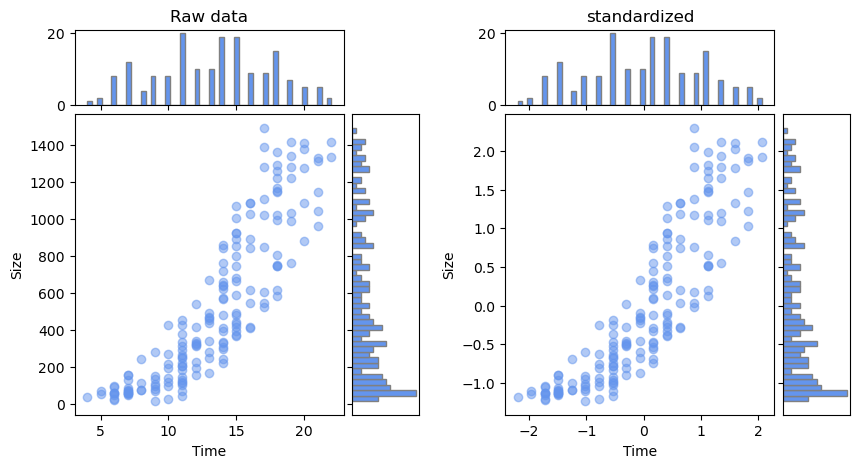

In [4]:
fig = plt.figure(figsize=(10, 5))
outer = gridspec.GridSpec(1, 2, wspace=0.25)

def scatter_with_marginals(gs, x_data, y_data, title):
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=gs,
        width_ratios=[4, 1],
        height_ratios=[1, 4],
        wspace=0.05,
        hspace=0.05
    )

    ax_scatter = plt.Subplot(fig, inner[1, 0])
    ax_histx = plt.Subplot(fig, inner[0, 0], sharex=ax_scatter)
    ax_histy = plt.Subplot(fig, inner[1, 1], sharey=ax_scatter)

    fig.add_subplot(ax_scatter)
    fig.add_subplot(ax_histx)
    fig.add_subplot(ax_histy)

    # Scatter
    ax_scatter.scatter(x_data, y_data, c='cornflowerblue', alpha=0.5)

    # Marginals
    ax_histx.hist(x_data, bins=50, histtype='step', fill=True, color='cornflowerblue', edgecolor='gray')
    ax_histy.hist(y_data, bins=50, orientation='horizontal', fill=True, color='cornflowerblue', edgecolor='gray')

    # Clean up ticks
    plt.setp(ax_histx.get_xticklabels(), visible=False)
    plt.setp(ax_histy.get_yticklabels(), visible=False)

    ax_histx.set_title(title)
    ax_scatter.set_xlabel('Time')
    ax_scatter.set_ylabel('Size')
    ax_histy.set_xticks([])

# Plot the orginal data
scatter_with_marginals(outer[0], t, size, "Raw data")

# standardization
norm_t = t - np.mean(t)
norm_t /= np.std(t)

norm_size = size - np.mean(size)
norm_size /= np.std(norm_size)

scatter_with_marginals(outer[1], norm_t, norm_size, "standardized")

In [5]:
n_train_samples = int(0.8*len(norm_t))
x_tensor = torch.from_numpy(np.expand_dims(norm_t, 1)).float()
y_tensor = torch.from_numpy(np.expand_dims(norm_size, 1)).float()

x_train = x_tensor[:n_train_samples]
y_train = y_tensor[:n_train_samples]
x_test = x_tensor[n_train_samples:]
y_test = y_tensor[n_train_samples:]
batch_size = 32

In [6]:

class SimpleNonlinearNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(1, 2),   # First hidden layer
            torch.nn.ReLU(),
            torch.nn.Linear(2, 1)    # Output layer
        )
    
    def forward(self, x):
        return self.model(x)

In [7]:

class MoreNonlinearNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(1, 4),   # First hidden layer
            torch.nn.ReLU(),
            # torch.nn.Linear(4, 4),   # Second hidden layer
            # torch.nn.ReLU(),
            torch.nn.Linear(4, 1),   # Second hidden layer

        )
    
    def forward(self, x):
        return self.model(x)

In [8]:
model_simple = SimpleNonlinearNN()
model_2 = MoreNonlinearNN()

In [9]:
criterion = torch.nn.MSELoss(size_average = False)
optimizer1 = torch.optim.SGD(model_simple.parameters(), lr = 0.001)
optimizer2 = torch.optim.SGD(model_2.parameters(), lr = 0.001)

/opt/homebrew/Caskroom/miniconda/base/envs/tuto_ml/lib/python3.11/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


In [10]:
def train_model(model, batch_size, optimizer):
    losses_steps = []
    losses_epochs = []

    for epoch in range(50):
        loss_epoch = 0

        #shuffle the trainig data each epoch for better stochasticity
        indices = np.random.permutation(n_train_samples)
        x_shuffled = x_tensor[indices]
        y_shuffled = y_tensor[indices]

        # loop through the dataset per batch
        for i, start_idx in enumerate(range(0, n_train_samples, batch_size)):
            
            # take only the current batch
            end_idx = start_idx + batch_size
            x_batch = x_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            # use the model to predict on the batch
            pred_y = model(x_batch)

            # Compute the loss on the batch and log it
            loss = criterion(pred_y, y_batch)
            loss_epoch += loss.detach().numpy()
            losses_steps.append(loss.detach().numpy())

            # Zero gradients (not accumulate)
            optimizer.zero_grad()
            
            # compute the gradients
            loss.backward()

            # apply the gradients to optimise
            optimizer.step()
            
        # Compute the mean loss on the epoch
        losses_epochs.append(loss_epoch / i)
    return losses_epochs, losses_steps


In [11]:
losses_epochs_1, losses_steps_1 = train_model(model_simple, 32, optimizer1)
losses_epochs_2, losses_steps_2 = train_model(model_2, 32, optimizer2)

Text(0.5, 1.0, 'Loss per epochs')

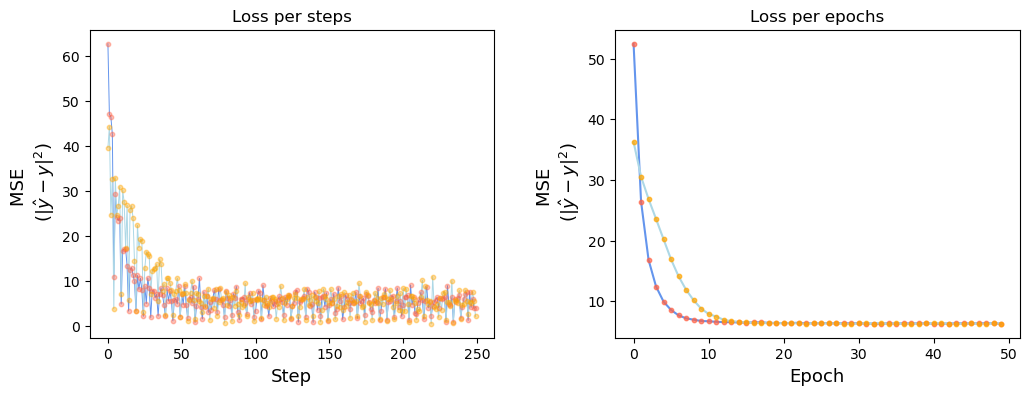

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.3)
ax[0].scatter(np.arange(len(losses_steps_1)), losses_steps_1, alpha=0.4, s=10, c='tomato', zorder=5)
ax[0].plot(np.arange(len(losses_steps_1)), losses_steps_1, c='cornflowerblue', lw=.7)
ax[0].scatter(np.arange(len(losses_steps_2)), losses_steps_2, alpha=0.4, s=10, c='orange', zorder=5)
ax[0].plot(np.arange(len(losses_steps_2)), losses_steps_2, c='lightblue', lw=.7)

ax[1].scatter(np.arange(len(losses_epochs_1)), losses_epochs_1, alpha=0.7, s=10, c='tomato', zorder=5)
ax[1].plot(np.arange(len(losses_epochs_1)), losses_epochs_1, c='cornflowerblue')
ax[1].scatter(np.arange(len(losses_epochs_2)), losses_epochs_2, alpha=0.7, s=10, c='orange', zorder=5)
ax[1].plot(np.arange(len(losses_epochs_2)), losses_epochs_2, c='lightblue')

[axe.set_ylabel('MSE \n ($|\hat{y} - y|^2)$', fontsize=13) for axe in ax]
ax[0].set_xlabel('Step', fontsize=13)
ax[1].set_xlabel('Epoch', fontsize=13)

ax[0].set_title('Loss per steps')
ax[1].set_title('Loss per epochs')

In [13]:
pred_on_train1 = model_simple(x_train)
pred_on_test1 = model_simple(x_test)

pred_on_train2 = model_2(x_train)
pred_on_test2 = model_2(x_test)

In [14]:
x_train.detach().numpy().shape

(138, 1)

Text(0.5, 1.0, 'On the test set')

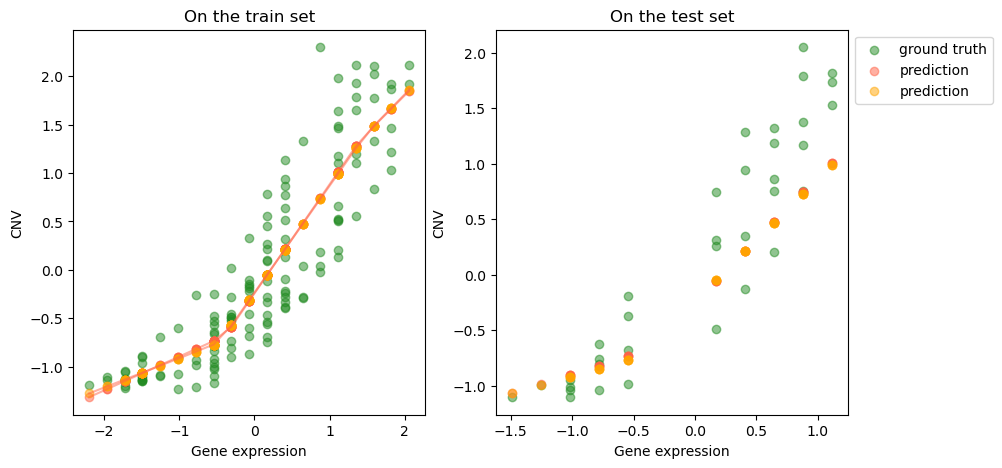

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
train_sort = np.argsort(x_train.detach().numpy()[:, 0])
ax[0].scatter(x_train, y_train, color='forestgreen', alpha=0.5, label='ground truth')
ax[0].scatter(x_train, pred_on_train1.detach().numpy(), color='tomato', alpha=0.5, label='prediction')
ax[0].plot(x_train[train_sort], pred_on_train1.detach().numpy()[train_sort], color='tomato', alpha=0.5, label='prediction')
ax[0].scatter(x_train, pred_on_train2.detach().numpy(), color='orange', alpha=0.5, label='prediction')
ax[0].plot(x_train[train_sort], pred_on_train2.detach().numpy()[train_sort], color='tomato', alpha=0.5, label='prediction')

ax[1].scatter(x_test, y_test, color='forestgreen', alpha=0.5, label='ground truth')
ax[1].scatter(x_test, pred_on_test1.detach().numpy(), color='tomato', alpha=0.5, label='prediction')
ax[1].scatter(x_test, pred_on_test2.detach().numpy(), color='orange', alpha=0.5, label='prediction')

ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left')

[axe.set_xlabel('Gene expression') for axe in ax]
[axe.set_ylabel('CNV') for axe in ax]

ax[0].set_title('On the train set')
ax[1].set_title('On the test set')


In [16]:
# data = pd.read_csv('./data/GDSC2_public_raw_data_27Oct23.csv', index_col=0)
# data

In [17]:
# cell_line = 'SIDM01042'
# drug_ID = 1617
# # sub_data = data[data['SANGER_MODEL_ID'] == cell_line]
# sub_data = data[data['CELL_LINE_NAME'] == 'HCC-827']

In [18]:

# sub_data = sub_data[sub_data['DRUG_ID'] == 1941]
# # sub_data = data[data['DRUG_ID'] == drug_ID]
# sub_data

In [19]:
# plt.scatter(sub_data['CONC'].values, sub_data['INTENSITY'].values)

In [20]:
# sub_data[sub_data['DRUG_ID'] == 1617]

In [21]:
# data['DRUG_ID'].values[~np.isnan(data['DRUG_ID'])]

In [22]:
# sub_data['DRUG_ID'].values[~np.isnan(data['DRUG_ID'])]

In [23]:
# data.columns